# Week 9: House Price Prediction

**Objective:** Predict house prices using supervised machine learning.

This notebook is prepared for the internship submission. It includes:
- dataset loading and basic checks
- preprocessing of numerical and categorical features
- train-test split
- Linear Regression
- Linear Regression from scratch (gradient-free normal-equation version)
- evaluation using MAE, MSE and R²
- cross-validation
- Polynomial Regression
- Decision Tree Regressor
- Random Forest Regressor
- predictions vs actual visualization
- feature interpretation
- model comparison

**Note:** This notebook is intentionally unexecuted in the starter package. Run it to generate the actual analysis, metrics, plots and conclusions.


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
TEST_SIZE = 0.20


In [2]:
# Load dataset
df = pd.read_csv("house_prices.csv")

print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Shape: (300, 8)


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000



Columns:
['Property_ID', 'Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location', 'Property_Type', 'Price']


In [3]:
# Basic data checks
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nBasic statistics:")
display(df.describe(include="all"))


Data types:


Property_ID        str
Area             int64
Bedrooms         int64
Bathrooms        int64
Age              int64
Location           str
Property_Type      str
Price            int64
dtype: object


Missing values:


Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64


Duplicate rows: 0

Basic statistics:


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
count,300,300.00000,300.000000,300.000000,300.000000,300,300,3.000000e+02
unique,300,NaN,NaN,NaN,NaN,3,3,NaN
top,PROP0001,NaN,NaN,NaN,NaN,Suburb,House,NaN
freq,1,NaN,NaN,NaN,NaN,105,107,NaN
mean,NaN,2759.70000,3.033333,2.026667,25.000000,NaN,NaN,2.488366e+07
std,NaN,1297.68143,1.467219,0.792495,14.332646,NaN,NaN,1.266525e+07
min,NaN,520.00000,1.000000,1.000000,0.000000,NaN,NaN,3.695000e+06
25%,NaN,1675.75000,2.000000,1.000000,12.000000,NaN,NaN,1.527750e+07
50%,NaN,2738.00000,3.000000,2.000000,25.500000,NaN,NaN,2.236500e+07
75%,NaN,3801.25000,4.000000,3.000000,36.250000,NaN,NaN,3.460812e+07


## 1. Understand the Data

The target variable is `Price`. The remaining useful property attributes are used as predictors. `Property_ID` is an identifier and is excluded from model training.


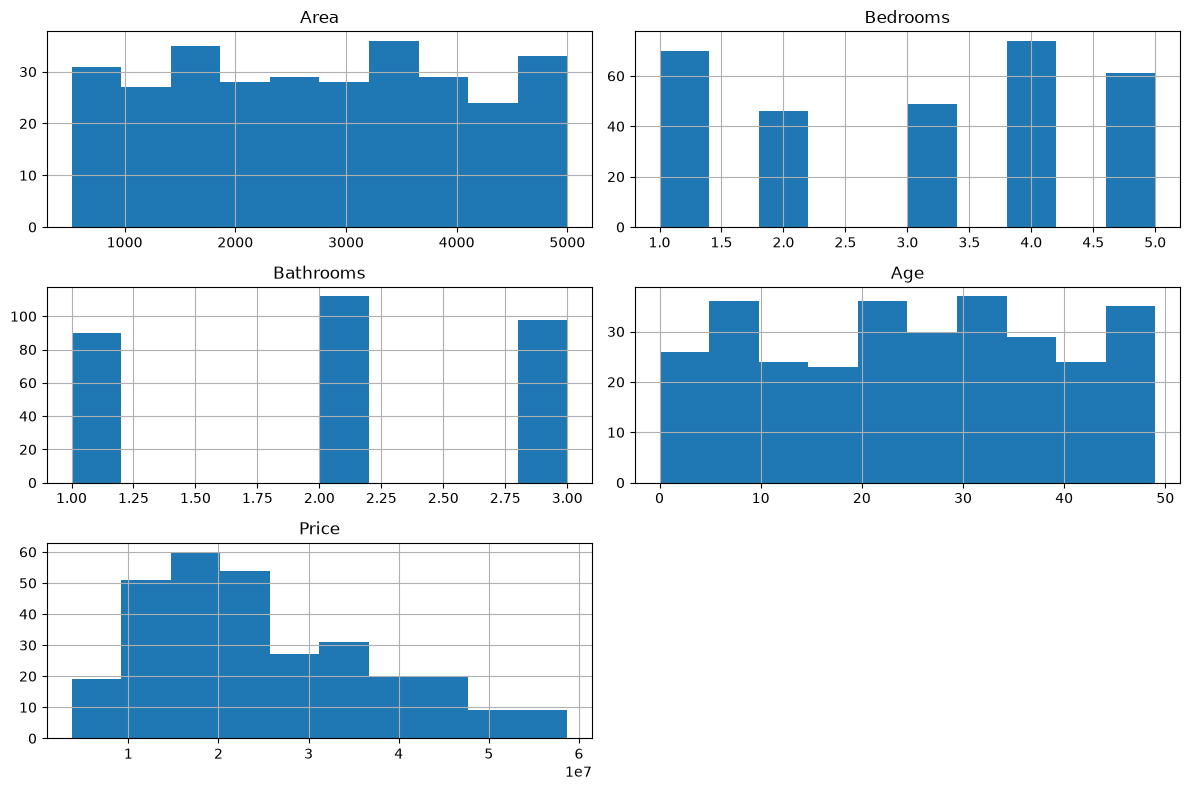

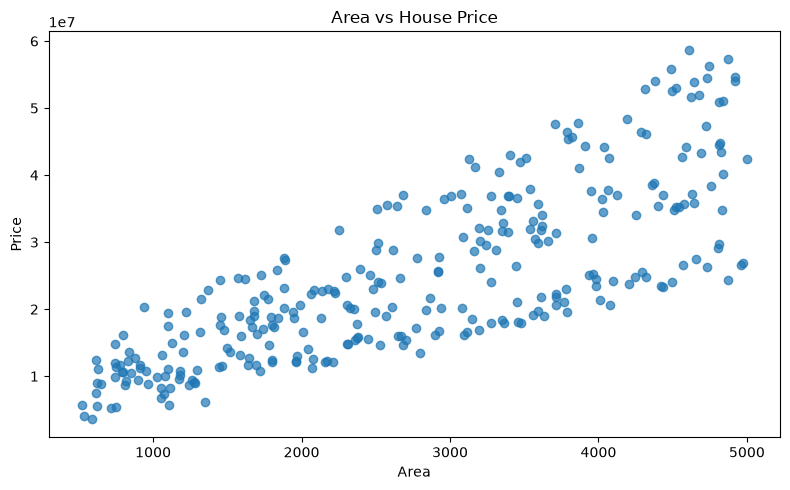

In [4]:
# Basic relationship visualization
numeric_cols = [c for c in ["Area", "Bedrooms", "Bathrooms", "Age", "Price"] if c in df.columns]

if len(numeric_cols) >= 2:
    df[numeric_cols].hist(figsize=(12, 8))
    plt.tight_layout()
    plt.show()

if "Area" in df.columns and "Price" in df.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(df["Area"], df["Price"], alpha=0.7)
    plt.xlabel("Area")
    plt.ylabel("Price")
    plt.title("Area vs House Price")
    plt.tight_layout()
    plt.show()


In [5]:
# Prepare features and target
target = "Price"
drop_cols = [c for c in ["Property_ID", target] if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[target]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['Area', 'Bedrooms', 'Bathrooms', 'Age']
Categorical features: ['Location', 'Property_Type']


In [6]:
# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 240
Testing rows: 60


## 2. Linear Regression From Scratch

For a simple numerical demonstration, Linear Regression can be represented as:

**ŷ = Xβ**

The least-squares solution is:

**β = (XᵀX)⁻¹Xᵀy**

The function below uses the pseudo-inverse, which is numerically safer than directly calculating a matrix inverse.


In [7]:
# Linear Regression from scratch using the normal equation
def linear_regression_from_scratch(X_train_numeric, y_train):
    X_np = np.asarray(X_train_numeric, dtype=float)
    y_np = np.asarray(y_train, dtype=float).reshape(-1, 1)

    # Add intercept column
    X_design = np.c_[np.ones(X_np.shape[0]), X_np]

    # Pseudo-inverse based least squares solution
    beta = np.linalg.pinv(X_design) @ y_np
    return beta.ravel()

def predict_from_scratch(X_numeric, beta):
    X_np = np.asarray(X_numeric, dtype=float)
    X_design = np.c_[np.ones(X_np.shape[0]), X_np]
    return X_design @ beta

# Demonstration on numeric features only
X_num = df[numeric_features].copy()
X_num = X_num.fillna(X_num.median())

X_num_train, X_num_test, y_num_train, y_num_test = train_test_split(
    X_num, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

beta = linear_regression_from_scratch(X_num_train, y_num_train)
scratch_predictions = predict_from_scratch(X_num_test, beta)

print("Scratch-model MAE:", mean_absolute_error(y_num_test, scratch_predictions))
print("Scratch-model R²:", r2_score(y_num_test, scratch_predictions))


Scratch-model MAE: 5957857.816723701
Scratch-model R²: 0.6190227024972201


## 3. Linear Regression with scikit-learn

In [8]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)


In [9]:
# Evaluation helper
def evaluate_model(name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, predictions)

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

results = []
results.append(evaluate_model("Linear Regression", y_test, linear_predictions))

results_df = pd.DataFrame(results)
display(results_df)


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,2.188736e+06,8.454331e+12,2.907633e+06,0.940637


## 4. Cross-Validation

In [10]:
# 5-fold cross-validation for the baseline Linear Regression model
cv_r2 = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("5-fold CV R² scores:", cv_r2)
print("Mean CV R²:", cv_r2.mean())
print("Std CV R²:", cv_r2.std())


5-fold CV R² scores: [0.95159597 0.92574613 0.95927496 0.94932502 0.95099707]
Mean CV R²: 0.9473878296550332
Std CV R²: 0.01135037111400097


## 5. Polynomial Regression

Polynomial features are applied to numerical inputs to test whether a simple non-linear relationship improves the baseline model.


In [11]:
poly_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

poly_model = Pipeline(steps=[
    ("preprocessor", poly_preprocessor),
    ("model", LinearRegression())
])

poly_model.fit(X_train, y_train)
poly_predictions = poly_model.predict(X_test)
results.append(evaluate_model("Polynomial Regression", y_test, poly_predictions))


## 6. Decision Tree and Random Forest

In [12]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=6
    ))
])

forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        max_depth=10,
        n_jobs=-1
    ))
])

tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)
forest_predictions = forest_model.predict(X_test)

results.append(evaluate_model("Decision Tree", y_test, tree_predictions))
results.append(evaluate_model("Random Forest", y_test, forest_predictions))

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
display(results_df)


,Model,MAE,MSE,RMSE,R2
3,Random Forest,1.472445e+06,3.974194e+12,1.993538e+06,0.972095
0,Linear Regression,2.188736e+06,8.454331e+12,2.907633e+06,0.940637
2,Decision Tree,2.491788e+06,9.603067e+12,3.098882e+06,0.932571
1,Polynomial Regression,2.367902e+06,1.011615e+13,3.180590e+06,0.928968


## 7. Predictions vs Actual Values

The following plot is required for the internship submission.


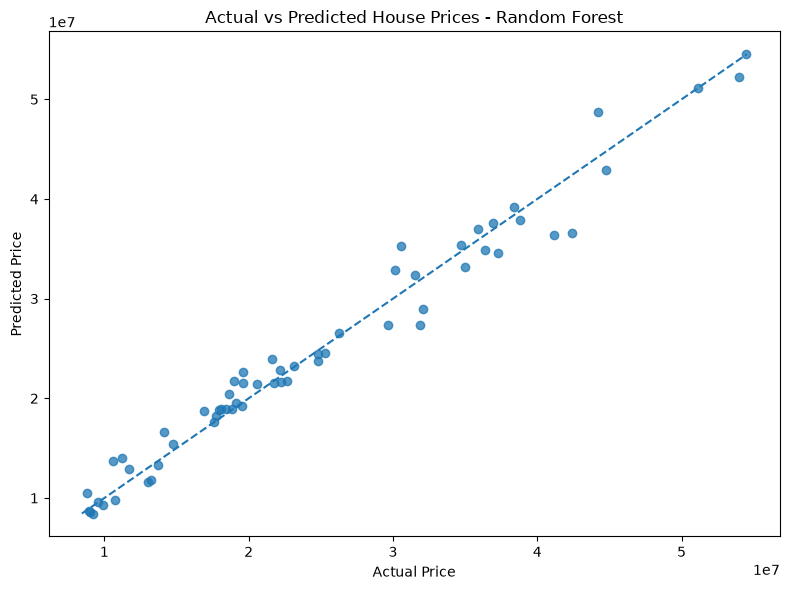

In [13]:
# Select the best model according to test R²
prediction_map = {
    "Linear Regression": linear_predictions,
    "Polynomial Regression": poly_predictions,
    "Decision Tree": tree_predictions,
    "Random Forest": forest_predictions
}

best_model_name = results_df.iloc[0]["Model"]
best_predictions = prediction_map[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_predictions, alpha=0.75)

min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted House Prices - {best_model_name}")
plt.tight_layout()
plt.savefig("predictions_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Model Performance

In [14]:
# Final metrics table
results_df = results_df.reset_index(drop=True)
display(results_df)

print("Best model:", best_model_name)
print("Best model R²:", results_df.iloc[0]["R2"])
print("Best model MAE:", results_df.iloc[0]["MAE"])
print("Best model MSE:", results_df.iloc[0]["MSE"])


,Model,MAE,MSE,RMSE,R2
0,Random Forest,1.472445e+06,3.974194e+12,1.993538e+06,0.972095
1,Linear Regression,2.188736e+06,8.454331e+12,2.907633e+06,0.940637
2,Decision Tree,2.491788e+06,9.603067e+12,3.098882e+06,0.932571
3,Polynomial Regression,2.367902e+06,1.011615e+13,3.180590e+06,0.928968


Best model: Random Forest
Best model R²: 0.9720948203563134
Best model MAE: 1472445.2901785711
Best model MSE: 3974194239392.33


## 9. Feature Interpretation

For the baseline Linear Regression model, the transformed feature names and coefficients can be inspected. This helps identify which encoded features have stronger positive or negative relationships with predicted price.


In [15]:
# Inspect Linear Regression coefficients
fitted_preprocessor = linear_model.named_steps["preprocessor"]
fitted_regressor = linear_model.named_steps["model"]

try:
    feature_names = fitted_preprocessor.get_feature_names_out()
    coefficients = fitted_regressor.coef_

    coefficient_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    coefficient_df["Absolute_Coefficient"] = coefficient_df["Coefficient"].abs()
    coefficient_df = coefficient_df.sort_values(
        "Absolute_Coefficient", ascending=False
    )

    display(coefficient_df.head(15))
except Exception as e:
    print("Feature interpretation unavailable:", e)


,Feature,Coefficient,Absolute_Coefficient
0,num__Area,9.833931e+06,9.833931e+06
4,cat__Location_City Center,8.453714e+06,8.453714e+06
5,cat__Location_Rural,-8.274417e+06,8.274417e+06
1,num__Bedrooms,2.320134e+06,2.320134e+06
3,num__Age,-1.165515e+06,1.165515e+06
8,cat__Property_Type_House,-4.265108e+05,4.265108e+05
2,num__Bathrooms,3.591435e+05,3.591435e+05
9,cat__Property_Type_Villa,2.451179e+05,2.451179e+05
7,cat__Property_Type_Apartment,1.813929e+05,1.813929e+05
6,cat__Location_Suburb,-1.792977e+05,1.792977e+05


## 10. Final Insights

After running the notebook, record:
1. Which model achieved the best R²?
2. Which model had the lowest MAE?
3. Which features appear most influential?
4. How close are predicted prices to actual prices?
5. What limitations remain?

Copy the final observations into `model_evaluation_report.md`.
